# MINTERPY/n-dimensional fitting for PCO M-60 neutral loss fragmentation data

In [1]:
# basic python packages
import numpy as np
import pandas as pd

# specific python packages
import minterpy as mp
import cvxpy as cp
# added by Damar for handling equations
import sympy as sp

# visualisation tools
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.widgets  import RectangleSelector
from minterpy.core.utils import get_exponent_matrix
import matplotlib.patches as patches

# others
import minterpy_functions as mf
import pickle

## PCO M-60 NL data fitting

In [2]:
# import FA anion fragment data via csv
df = pd.read_csv(r"./frag_data/220421_PCO_M60.csv").dropna(axis=1)
cols = ['CE', 'FA_C', 'FA_DB', 'FA_iso']

# analyte information to_numpy()
sample_points = df[cols].to_numpy()
function_vals = df['norm_Intensity'].to_numpy()

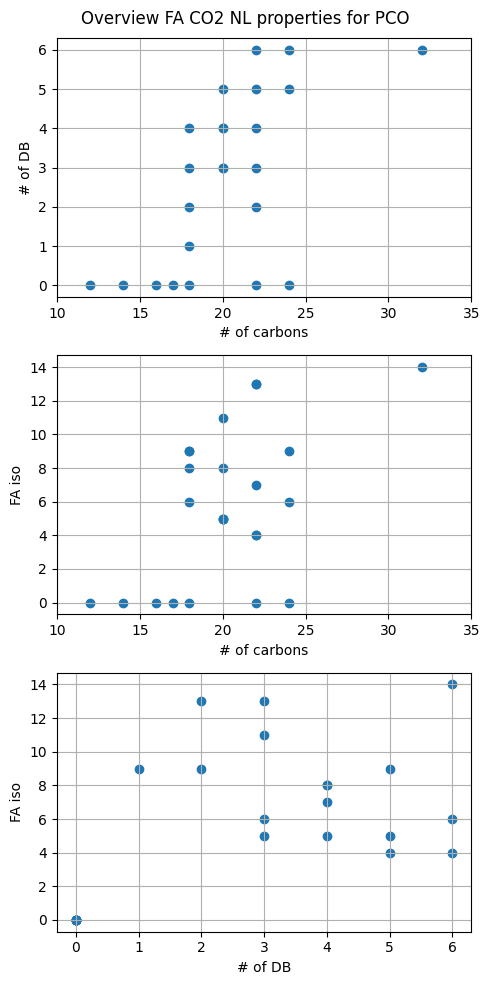

In [3]:
## get dataframe with needed properties
overview_df = df[['FA_C', 'FA_DB', 'FA_iso']].drop_duplicates()

fig, ax = plt.subplots(3,1, figsize=(5,10))

fig.suptitle('Overview FA CO2 NL properties for PCO')

# plot number of carbons vs number of DB
ax = plt.subplot(3,1,1) 
plt.scatter(overview_df.FA_C, overview_df.FA_DB)
ax.set_xlim(10,35)
ax.set_xlabel('# of carbons')
ax.set_ylabel('# of DB')
ax.grid(which='both')

# plot number of carbons vs DB position
ax = plt.subplot(3,1,2) 
plt.scatter(overview_df.FA_C, overview_df.FA_iso)
ax.set_xlim(10,35)
ax.set_xlabel('# of carbons')
ax.set_ylabel('FA iso')
ax.grid(which='both')

# plot number of DB vs DB position
ax = plt.subplot(3,1,3) 
plt.scatter(overview_df.FA_DB, overview_df.FA_iso)
ax.set_xlabel('# of DB')
ax.set_ylabel('FA iso')
ax.grid(which='both')

plt.tight_layout()
plt.show()

In [4]:
a_uni = np.array(overview_df.sort_values(by=['FA_C', 'FA_DB', 'FA_iso']))
a_uni

array([[12,  0,  0],
       [14,  0,  0],
       [16,  0,  0],
       [17,  0,  0],
       [18,  0,  0],
       [18,  1,  9],
       [18,  2,  9],
       [18,  3,  6],
       [18,  4,  8],
       [20,  3,  5],
       [20,  3, 11],
       [20,  4,  5],
       [20,  4,  8],
       [20,  5,  5],
       [22,  0,  0],
       [22,  2, 13],
       [22,  3, 13],
       [22,  4,  7],
       [22,  5,  4],
       [22,  6,  4],
       [24,  0,  0],
       [24,  5,  9],
       [24,  6,  6],
       [32,  6, 14]])

## MINTERPY/n-dimensional fitting of PCO FA fragment data

In [5]:
sparse_poly_model = mf.lasso_fit_data(sample_points,
                                       function_vals, 
                                       poly_degree_along=[8,2,2,0], ## PCO FA with 8.3.2.2; degree could be lower here => no major changes
                                       weighted=True)

Optimizer result : 228.71986468722434


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/minterpy/schemes/barycentric/operators.py:47: UserWarning: building a full transformation matrix from a barycentric transformation. this is inefficient.
  warn(


In [6]:
print(sparse_poly_model)
lower_bounds = np.round(np.amin(sample_points, axis=0))
upper_bounds = np.round(np.amax(sample_points, axis=0))+1.0

eval_vals = mf.poly_evaluate_at(sparse_poly_model, sample_points, lower_bounds, upper_bounds)
print(sample_points)
print(eval_vals)

[[10 12  0  0]
 [11 12  0  0]
 [12 12  0  0]
 ...
 [31 32  6 14]
 [32 32  6 14]
 [33 32  6 14]]
[ 4.91715821  5.3244418   5.64325743  5.88270453  6.05042322  6.1527359
  6.19477714  6.18061192  6.11334216  5.99520166  5.82763927  5.61139049
  5.34653728  5.0325563   4.66835545  4.25229873  3.78221939  3.25542153
  2.66866986  2.01816792  1.29952461  0.50770898 -0.36300658 -1.31911488
 -2.36795405 -3.51779943 -4.77796711 -6.15892907  4.80985891  5.23947669
  5.57902773  5.83762838  6.02293568  6.14128894  6.19783966  6.19666973
  6.140898    6.03277519  5.87376708  5.66462607  5.40545104  5.09573559
  4.73440453  4.31983877  3.84988851  3.32187473  2.73257908  2.07822204
  1.3544294   0.55618715 -0.32221542 -1.28725418 -2.34625035 -3.50746235
 -4.78018934 -6.17488639  4.70521558  5.15594906  5.51519679  5.79208846
  5.99429448  6.12816752  6.19887243  6.21050447  6.16619583  6.06821061
  5.91802793  5.71641354  5.46347971  5.15873338  4.80111271  4.38901199
  3.92029475  3.39229536  2.8

L_2 error of fitting SYM dataset = 0.2854483106378192
L_inf error of fitting SYM dataset = 9.127150058232253


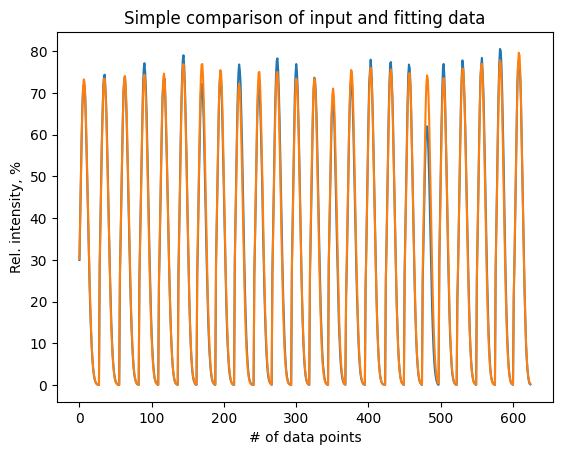

In [7]:
lower_bounds = np.round(np.amin(sample_points, axis=0))
upper_bounds = np.round(np.amax(sample_points, axis=0))+1.0

eval_vals = mf.poly_evaluate_at(sparse_poly_model, sample_points, lower_bounds, upper_bounds)

abs_errs = pow(2,eval_vals) - function_vals
rel_errs = np.divide(abs_errs, function_vals)

L2_error = np.linalg.norm(rel_errs, 1)/len(rel_errs)
Linf_error = np.max(np.abs(rel_errs))

print(f"L_2 error of fitting SYM dataset = {L2_error}")
print(f"L_inf error of fitting SYM dataset = {Linf_error}")

plt.title("Simple comparison of input and fitting data")
plt.plot(function_vals)
plt.plot(pow(2,eval_vals))
plt.xlabel("# of data points")
plt.ylabel("Rel. intensity, %")
plt.show()

## Visualization of fitting data/results

### Comparison of fragment intensities : measured vs calculated via MINTERPY/ndim fitting

#### Comparison for saturated FA

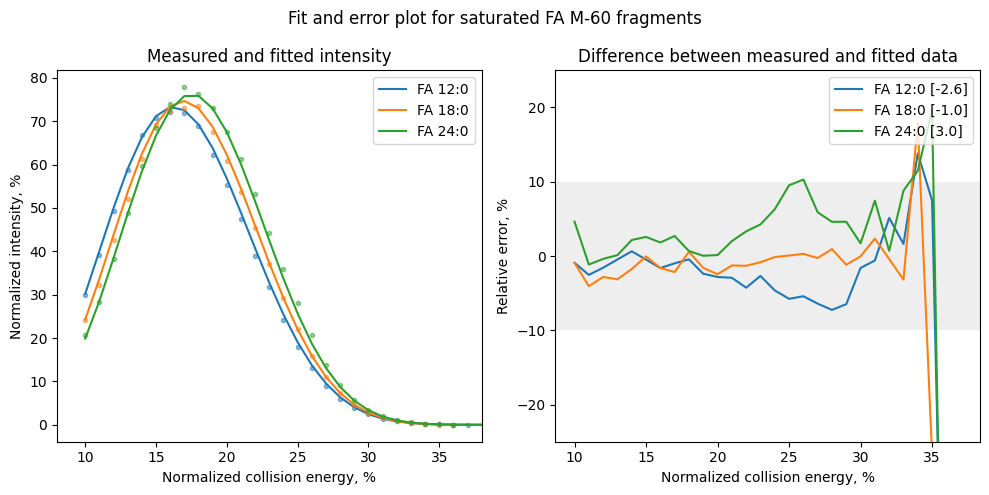

In [8]:
# color definition for plots
colors = [('tab:blue', '#1f77b4'), ('tab:orange', '#ff7f0e'), ('tab:green', '#2ca02c'), ('tab:red', '#d62728'), ('tab:purple', '#9467bd'), ('tab:brown', '#8c564b'), ('tab:pink', '#e377c2'), ('tab:gray', '#7f7f7f'), ('tab:olive', '#bcbd22'), ('tab:cyan', '#17becf')]

nce = [10,70] # range of nce
FA_oi = [[12, 0, 0], [18, 0, 0], [24, 0, 0]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Fit and error plot for saturated FA M-60 fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])
    ax[0].set_xlim(8,38)

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(15, 26).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

#### Comparison for FAs with 18 carbons and different DBs

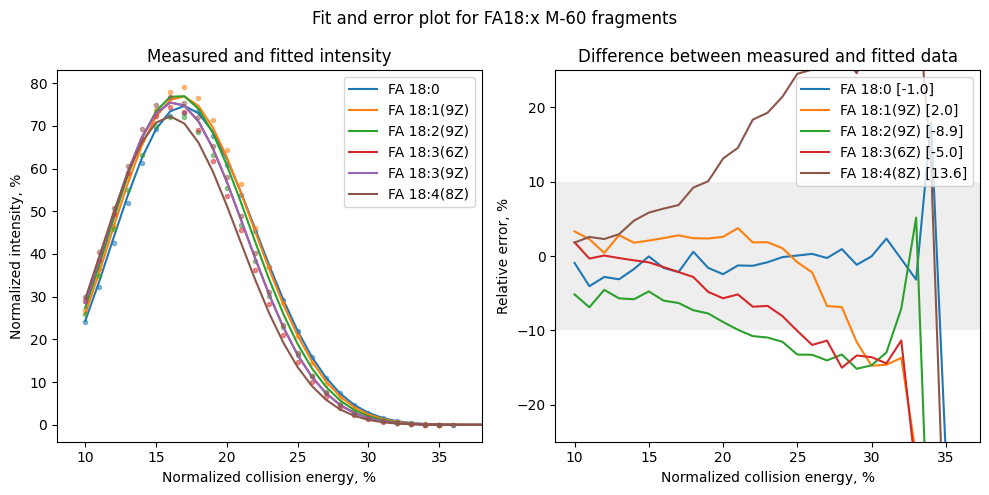

In [9]:
nce = [10,70] # range of nce
FA_oi = [[18, 0, 0], [18, 1, 9], [18, 2, 9], [18, 3, 6], [18, 3, 9], [18, 4, 8]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Fit and error plot for FA18:x M-60 fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])
    ax[0].set_xlim(8,38)

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(15, 26).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()


#### Comparison for FAs with 20 carbons and different DBs

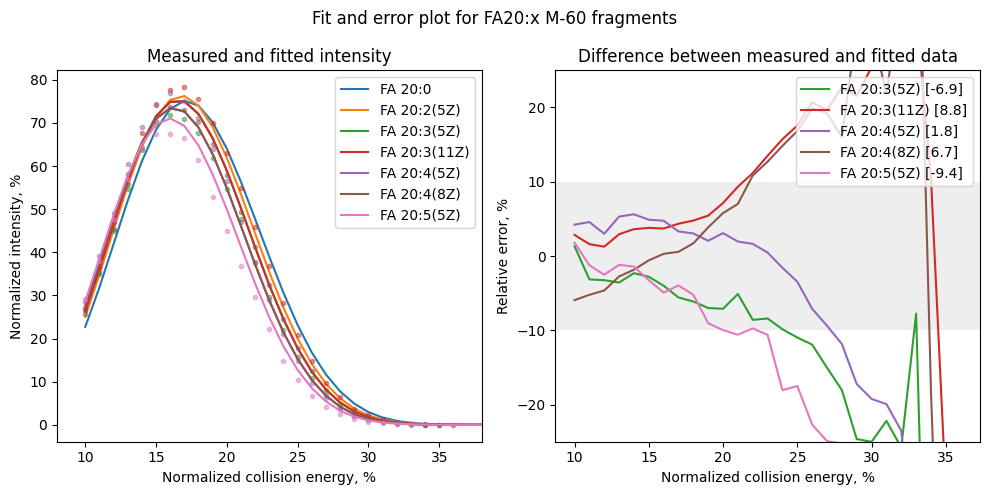

In [10]:
nce = [10,70] # range of nce
FA_oi = [[20, 0, 0], [20, 2, 5], [20, 3, 5], [20, 3, 11], [20, 4, 5], [20, 4, 8], [20, 5, 5]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Fit and error plot for FA20:x M-60 fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])
    ax[0].set_xlim(8,38)

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(15, 26).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()


#### Comparison for FAs with 22 carbons and different DBs

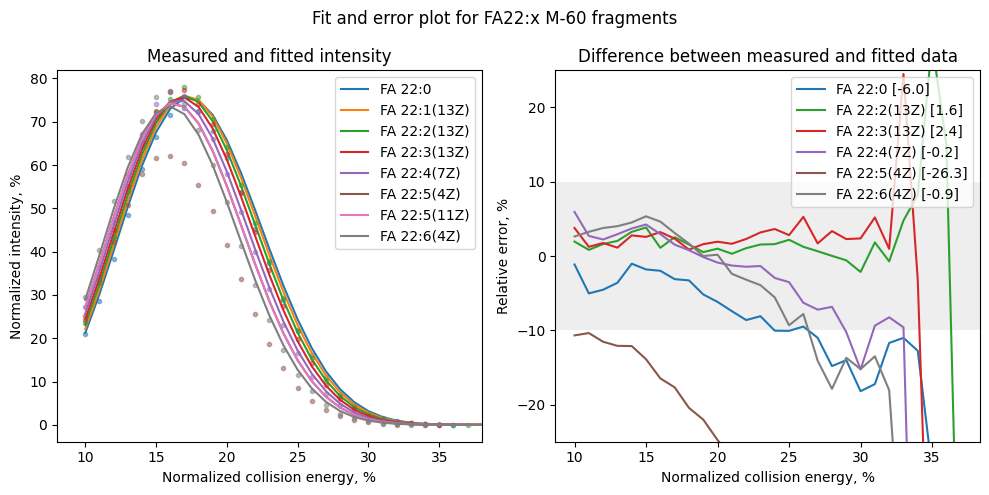

In [11]:
nce = [10,70] # range of nce
FA_oi = [[22, 0, 0], [22, 1, 13], [22, 2, 13], [22, 3, 13], [22, 4, 7], [22, 5, 4], [22, 5, 11], [22, 6, 4]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle("Fit and error plot for FA22:x M-60 fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])
    ax[0].set_xlim(8,38)

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(15, 26).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()


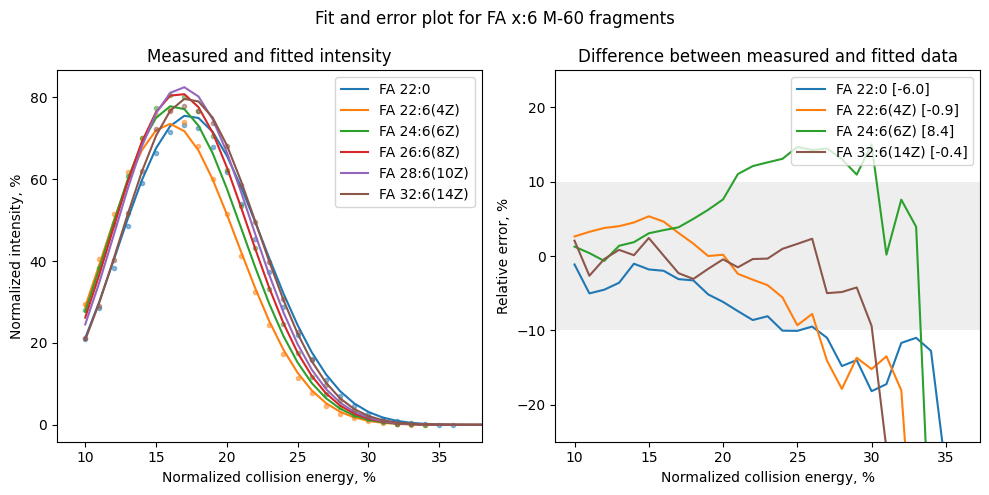

In [12]:
nce = [10,70] # range of nce
FA_oi = [[22, 0, 0], [22, 6, 4], [24, 6, 6], [26, 6, 8], [28, 6, 10], [32, 6, 14]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))
fig.suptitle("Fit and error plot for FA x:6 M-60 fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(sparse_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    if iso == 0:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    else:
        ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}({iso}Z)', color=colors[i][0])
    ax[0].set_xlim(8,38)

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(15, 26).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        if iso == 0:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} [{round(av, 1)}]', color=colors[i][0])
        else:
            ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB}({iso}Z) [{round(av, 1)}]', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

# highlight for range of average
x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Handling MINTERPYs ndim equations

### Convertion of NewtonPolynomials for 'equation' 

In [13]:
# Transformation of NewtonPolynomials to Canonical Form
model_can = mp.get_transformation(sparse_poly_model, mp.CanonicalPolynomial)()

print(sparse_poly_model.multi_index)

trimmed_coeffs = model_can.coeffs.copy()

# conditional coefficient modification, if needed
# trimmed_coeffs[np.where((trimmed_coeffs<1e0) & (trimmed_coeffs>-1e0))] = 0.0
# trimmed_coeffs = np.around(trimmed_coeffs, 2)

model_can.coeffs = trimmed_coeffs
model_eqn = mf.mp_to_sympy(model_can)

# conversion to equation
# print(model_eqn.coeffs())
model_eqn

MultiIndexSet
[[0 0 0 0]
 [1 0 0 0]
 [2 0 0 0]
 [3 0 0 0]
 [4 0 0 0]
 [5 0 0 0]
 [6 0 0 0]
 [7 0 0 0]
 [8 0 0 0]
 [0 1 0 0]
 [1 1 0 0]
 [2 1 0 0]
 [3 1 0 0]
 [4 1 0 0]
 [5 1 0 0]
 [6 1 0 0]
 [7 1 0 0]
 [0 2 0 0]
 [1 2 0 0]
 [2 2 0 0]
 [3 2 0 0]
 [4 2 0 0]
 [5 2 0 0]
 [6 2 0 0]
 [7 2 0 0]
 [0 0 1 0]
 [1 0 1 0]
 [2 0 1 0]
 [3 0 1 0]
 [4 0 1 0]
 [5 0 1 0]
 [6 0 1 0]
 [7 0 1 0]
 [0 1 1 0]
 [1 1 1 0]
 [2 1 1 0]
 [3 1 1 0]
 [4 1 1 0]
 [5 1 1 0]
 [6 1 1 0]
 [7 1 1 0]
 [0 2 1 0]
 [1 2 1 0]
 [2 2 1 0]
 [3 2 1 0]
 [4 2 1 0]
 [5 2 1 0]
 [6 2 1 0]
 [7 2 1 0]
 [0 0 2 0]
 [1 0 2 0]
 [2 0 2 0]
 [3 0 2 0]
 [4 0 2 0]
 [5 0 2 0]
 [6 0 2 0]
 [7 0 2 0]
 [0 1 2 0]
 [1 1 2 0]
 [2 1 2 0]
 [3 1 2 0]
 [4 1 2 0]
 [5 1 2 0]
 [6 1 2 0]
 [7 1 2 0]
 [0 2 2 0]
 [1 2 2 0]
 [2 2 2 0]
 [3 2 2 0]
 [4 2 2 0]
 [5 2 2 0]
 [6 2 2 0]
 [7 2 2 0]]


Poly(-1.34872560174186e-14*x_0**8 - 1.67731641161068e-13*x_0**7*x_1**2*x_2**2 + 2.35315676022109e-14*x_0**7*x_1**2*x_2 + 6.80652399702682e-14*x_0**7*x_1**2 + 8.33866976398451e-14*x_0**7*x_1*x_2**2 + 3.55271367880067e-15*x_0**7*x_1*x_2 + 1.12786365277024e-14*x_0**7*x_1 + 1.25205501354992e-13*x_0**7*x_2**2 - 4.24822298108302e-14*x_0**7*x_2 - 1.99622927269083e-13*x_0**7 - 1.03787187011341e-14*x_0**6*x_1**2*x_2**2 + 4.54730286083673e-15*x_0**6*x_1**2*x_2 + 2.19372340178884e-14*x_0**6*x_1**2 - 7.84931528563758e-15*x_0**6*x_1*x_2**2 + 1.33226762955017e-14*x_0**6*x_1*x_2 + 1.52287447711499e-14*x_0**6*x_1 - 1.02363592781334e-14*x_0**6*x_2**2 - 2.29371469623591e-15*x_0**6*x_2 - 0.122053344230131*x_0**6 - 3.58228259893484e-13*x_0**5*x_1**2*x_2**2 - 5.02338498513454e-15*x_0**5*x_1**2*x_2 + 1.66072598128315e-13*x_0**5*x_1**2 - 5.58405091910817e-14*x_0**5*x_1*x_2**2 - 6.02589400175109e-14*x_0**5*x_1*x_2 - 3.45810033152985e-14*x_0**5*x_1 + 0.032964650448241*x_0**5*x_2**2 + 6.7439290362516e-14*x_0**5

### Convertion of 'equation' to NewtonPolynomials

In [14]:
# conversion of pco_model_eqn to new "sparse_poly_model" called "test_equation" to see if we get back intensity values
test_poly_model = mf.sympy_to_mp(model_eqn, target_basis=mp.NewtonPolynomial)
print(sparse_poly_model.coeffs)

[-1.56678878e+01 -1.01399182e+01 -6.81126525e+00 -1.79379843e+00
 -1.02946851e+00  7.96724431e-02 -1.22053344e-01 -2.84217094e-13
  1.42108547e-14  2.78023341e+00  1.46935410e+00 -3.83250475e-01
 -3.64153152e-14  6.21724894e-15  3.55271368e-15  1.95399252e-14
  9.94759830e-14 -1.29890892e+00 -4.06608947e-01  1.80242121e-01
 -1.14923304e-01 -5.59552404e-14 -3.28626015e-13  1.59872116e-14
 -7.10542736e-14 -3.99772386e+00 -1.92255952e+00 -3.82634436e-01
 -1.22450240e-01 -2.48689958e-14  9.05941988e-14 -1.24344979e-14
 -2.13162821e-14  1.16162889e+00  4.96161070e-01 -5.99520433e-15
 -5.81756865e-14 -2.22044605e-15 -5.95079541e-14  1.33226763e-14
  3.55271368e-15 -8.20478667e-01 -2.79665961e-01 -1.06581410e-14
 -4.62361375e-02 -3.10862447e-15  3.19744231e-14  4.44089210e-15
  2.48689958e-14 -8.81056490e-01 -1.94555298e-01  3.42698772e-01
  4.94469757e-02 -6.57252031e-14  3.29646504e-02 -1.24344979e-14
 -1.20792265e-13  1.84745591e-01  1.86517468e-14 -1.62456651e-01
  5.41788836e-14 -2.22044

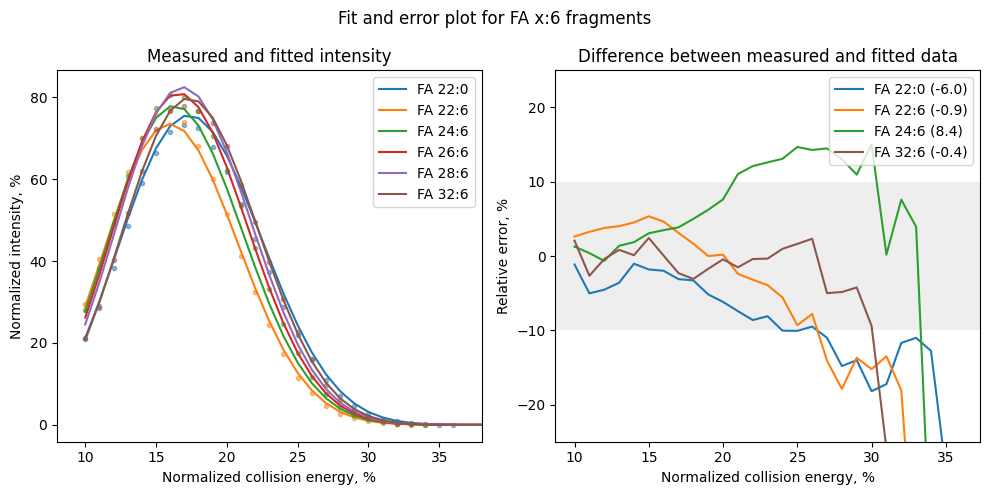

In [15]:
nce = [10,70] # range of nce
FA_oi = [[22, 0, 0], [22, 6, 4], [24, 6, 6], [26, 6, 8], [28, 6, 10], [32, 6, 14]]  # Input as list of lists
num_points_in_grid = 61

fig, ax = plt.subplots(1,2, figsize=(10,5))

fig.suptitle("Fit and error plot for FA x:6 fragments")

for i, (C, DB, iso) in enumerate(FA_oi):  # Unpack each list into C, DB, iso
    xvals = np.linspace(nce[0], nce[1], num_points_in_grid)
    eval_points = np.array([[x, C, DB, iso] for x in xvals])
    
    eval_vals = mf.poly_evaluate_at(test_poly_model, eval_points, lower_bounds, upper_bounds)
    calc_intensity = pow(2, eval_vals)

    # Plot calculated intensity
    ax[0].plot(xvals, calc_intensity, label=f'FA {C}:{DB}', color=colors[i][0])
    ax[0].set_xlim(8,38)

    # Subset and condition
    condition = (df.FA_C == C) & (df.FA_DB == DB) & (df.FA_iso == iso)
    
    if condition.sum() > 0:
        df_subset = df[condition]
        # Plot measured intensity
        ax[0].plot(df_subset.CE, df_subset.norm_Intensity, '.', alpha=0.5, color=colors[i][0])

        meas_subset = df_subset.reset_index()
        ces = np.arange(meas_subset.CE.min(), meas_subset.CE.max() + 1).astype(float)
        calc_int = pow(2, eval_vals[np.isin(xvals, ces)])

        diff = (meas_subset.norm_Intensity - calc_int) / calc_int * 100
        ces2 = np.arange(15, 26).astype(float)
        av = diff[meas_subset.CE.isin(ces2)].mean()
        
        # Plot delta intensity
        ax[1].plot(meas_subset.CE, diff, label=f'FA {C}:{DB} ({round(av, 1)})', color=colors[i][0])

ax[0].set(xlabel="Normalized collision energy, %", ylabel="Normalized intensity, %", title="Measured and fitted intensity")
ax[1].set(xlabel="Normalized collision energy, %", ylabel="Relative error, %", title="Difference between measured and fitted data", ylim=(-25, 25))

x = 0 ; y = -10 ; width = 100; height = 20; 
ax[1].add_patch(patches.Rectangle((x, y), width, height, facecolor='#eeeeee'))

for axis in ax:
    axis.legend(loc='upper right')
    

plt.tight_layout()
plt.show()

### Saving/export of polynomial functions as eg pickle

In [16]:
import json_tricks as json
# write polynomial coefficients and exponents to dictionary for export
poly_info = {'coeffs': sparse_poly_model.coeffs, 'exponents': sparse_poly_model.multi_index.exponents, 'lower_bounds': lower_bounds, 'upper_bounds': upper_bounds}

# with open('./polynomials/240916_PCO_M-60_poly_new.json', 'w') as f:
#     json.dump(poly_info, f)

# Storing the polynomial object in a file
pickle.dump(poly_info, open('./polynomials/240916_PCO_M-60_poly.pkl', 'wb'))

In [17]:
poly_info

{'coeffs': array([-1.56678878e+01, -1.01399182e+01, -6.81126525e+00, -1.79379843e+00,
        -1.02946851e+00,  7.96724431e-02, -1.22053344e-01, -2.84217094e-13,
         1.42108547e-14,  2.78023341e+00,  1.46935410e+00, -3.83250475e-01,
        -3.64153152e-14,  6.21724894e-15,  3.55271368e-15,  1.95399252e-14,
         9.94759830e-14, -1.29890892e+00, -4.06608947e-01,  1.80242121e-01,
        -1.14923304e-01, -5.59552404e-14, -3.28626015e-13,  1.59872116e-14,
        -7.10542736e-14, -3.99772386e+00, -1.92255952e+00, -3.82634436e-01,
        -1.22450240e-01, -2.48689958e-14,  9.05941988e-14, -1.24344979e-14,
        -2.13162821e-14,  1.16162889e+00,  4.96161070e-01, -5.99520433e-15,
        -5.81756865e-14, -2.22044605e-15, -5.95079541e-14,  1.33226763e-14,
         3.55271368e-15, -8.20478667e-01, -2.79665961e-01, -1.06581410e-14,
        -4.62361375e-02, -3.10862447e-15,  3.19744231e-14,  4.44089210e-15,
         2.48689958e-14, -8.81056490e-01, -1.94555298e-01,  3.42698772e-01,
  